# Diabetes Disease Prediction

Supervised ML pipeline on the Pima Indians Diabetes dataset (768 patients, 8 clinical
features). 



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load data

In [16]:
df = pd.read_csv("Diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [18]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [19]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

missing_before = pd.DataFrame({
    "n_zero_values": (df[zero_as_missing] == 0).sum(),
    "pct_zero": ((df[zero_as_missing] == 0).sum() / len(df) * 100).round(1)
})
missing_before

,n_zero_values,pct_zero
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


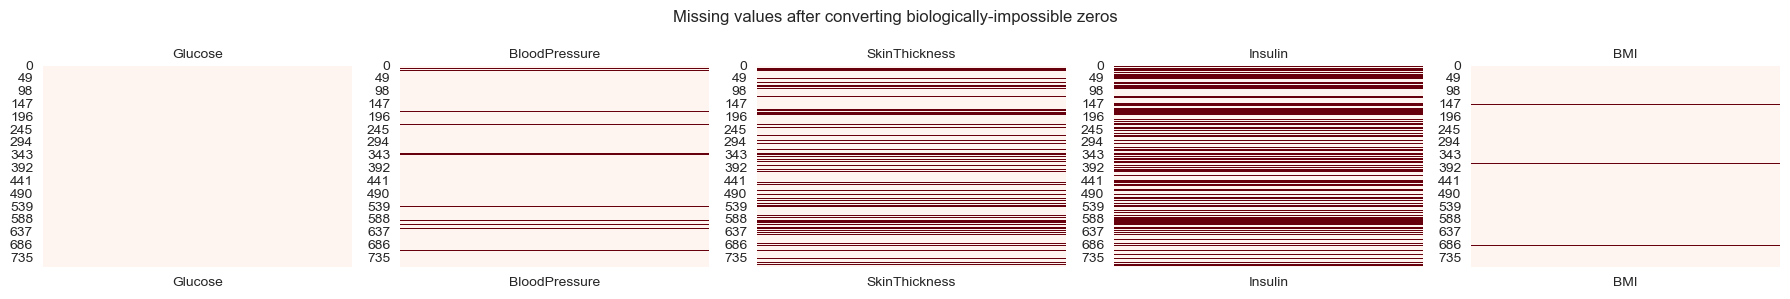

In [20]:
df_clean = df.copy()
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

fig, axes = plt.subplots(1, len(zero_as_missing), figsize=(18, 3))
for ax, col in zip(axes, zero_as_missing):
    sns.heatmap(df_clean[[col]].isna(), cbar=False, ax=ax, cmap="Reds")
    ax.set_title(col, fontsize=10)
plt.suptitle("Missing values after converting biologically-impossible zeros")
plt.tight_layout()
plt.show()

## 3. Exploratory data analysis

In [21]:
df["Outcome"].value_counts(normalize=True).mul(100).round(1)

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

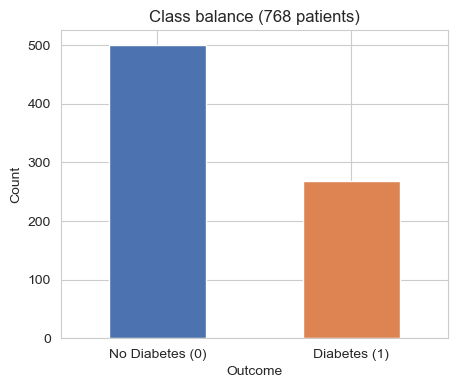

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Outcome"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Class balance ({len(df)} patients)")
plt.show()

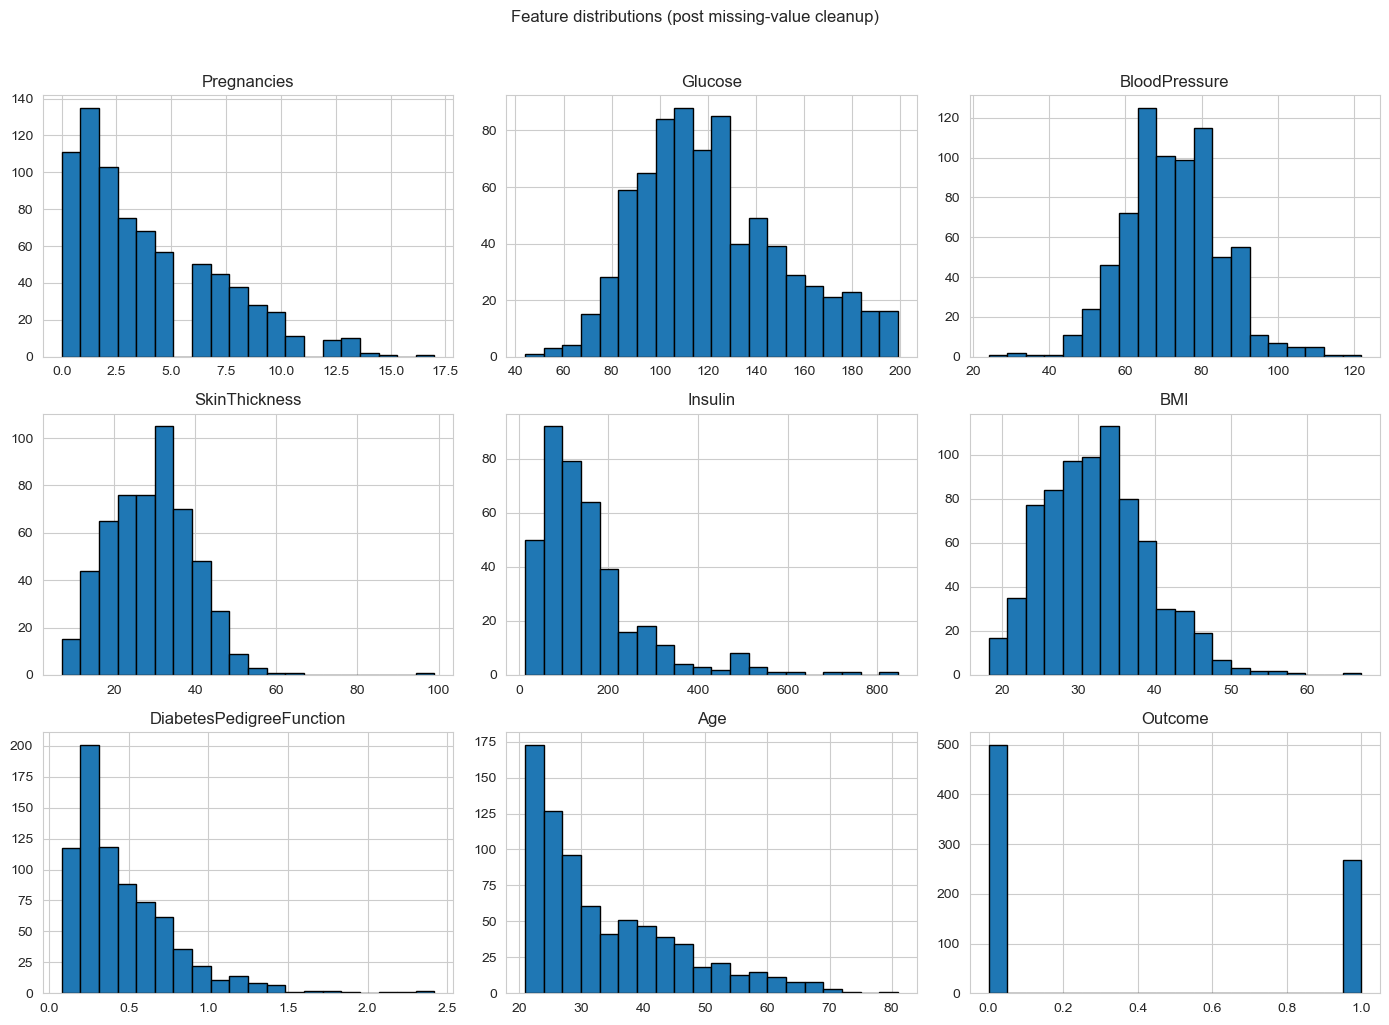

In [23]:
df_clean.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Feature distributions (post missing-value cleanup)", y=1.02)
plt.tight_layout()
plt.show()

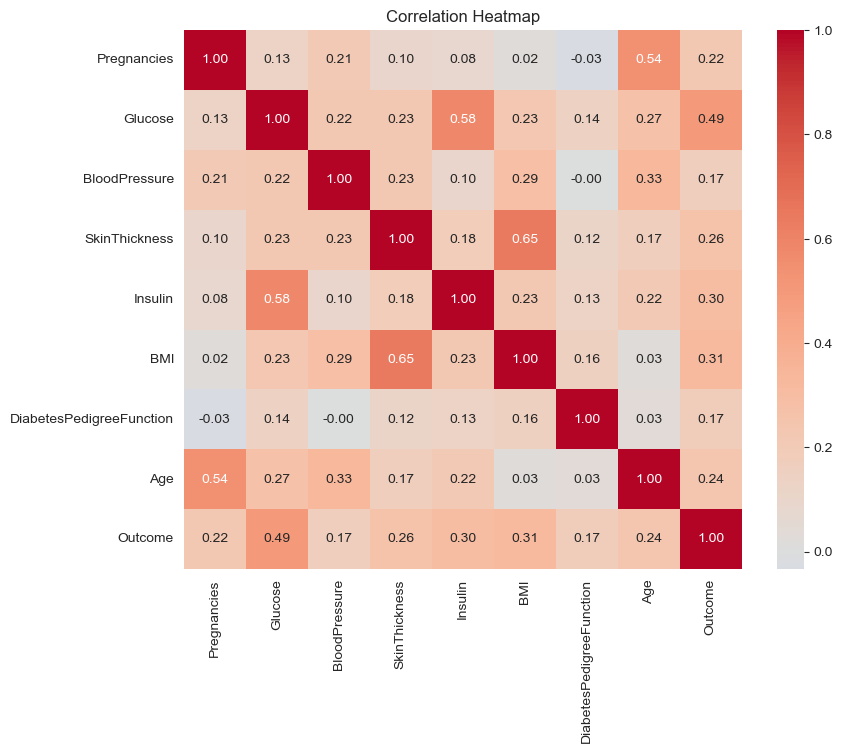

In [24]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

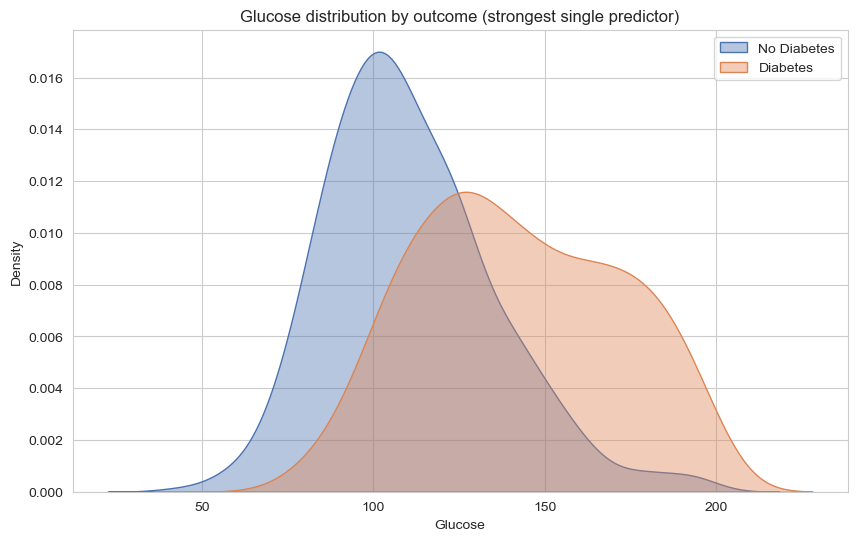

In [25]:
plt.figure(figsize=(10, 6))
for outcome, label, color in [(0, "No Diabetes", "#4C72B0"), (1, "Diabetes", "#DD8452")]:
    sns.kdeplot(df_clean.loc[df_clean["Outcome"] == outcome, "Glucose"].dropna(),
                label=label, fill=True, alpha=0.4, color=color)
plt.title("Glucose distribution by outcome (strongest single predictor)")
plt.xlabel("Glucose")
plt.legend()
plt.show()

## 4. Train/test split, imputation, scaling

Imputation and scaling are fit **only on the training set** and applied to the test set —
fitting on the full dataset before splitting would leak test-set information into
training (a common beginner mistake).

In [26]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X.columns, index=X_test.index)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test class balance:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Train: (614, 8), Test: (154, 8)
Train class balance: {0: 0.651, 1: 0.349}
Test class balance:  {0: 0.649, 1: 0.351}


## 5. Model comparison with stratified cross-validation

A single train/test split (what the original notebook used) gives one noisy estimate.
5-fold stratified cross-validation on the training set gives a much more trustworthy
picture of how each model actually performs, and lets us compare three algorithms fairly
before committing to one.

In [27]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "f1", "roc_auc"]

results = []
for name, model in models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring)
    results.append({
        "Model": name,
        "Accuracy": f"{scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}",
        "F1": f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}",
        "ROC-AUC": f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df

,Accuracy,F1,ROC-AUC
Model,,,
Logistic Regression,0.762 ± 0.011,0.672 ± 0.013,0.844 ± 0.016
Random Forest,0.765 ± 0.028,0.633 ± 0.035,0.821 ± 0.025
SVM (RBF),0.762 ± 0.033,0.693 ± 0.026,0.837 ± 0.030


## 6. Hyperparameter tuning

Random Forest is typically strongest on this dataset and gives free feature importances,
so we tune it with a grid search (5-fold CV, optimizing ROC-AUC).

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_

## 7. Final evaluation on the held-out test set

In [ ]:
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Test F1:       {f1_score(y_test, y_pred):.3f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}", color="#DD8452")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color="#4C72B0")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

## 8. Feature importance

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#4C72B0")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

## 9. Save the model and provide a usable inference function

Everything needed to score a new patient — imputer, scaler, and model — is bundled
together, so the pipeline is reproducible outside this notebook (e.g. in a small Flask/
Streamlit demo).

In [ ]:
joblib.dump({
    "model": best_model,
    "imputer": imputer,
    "scaler": scaler,
    "feature_names": list(X.columns),
}, "diabetes_model.joblib")

print("Saved diabetes_model.joblib")

In [ ]:
def predict_diabetes(patient: dict, bundle_path: str = "diabetes_model.joblib") -> dict:
    """
    Predict diabetes risk for a single patient.

    patient: dict with keys Pregnancies, Glucose, BloodPressure, SkinThickness,
             Insulin, BMI, DiabetesPedigreeFunction, Age
    Returns: dict with prediction (0/1) and probability of diabetes.
    """
    bundle = joblib.load(bundle_path)
    X_new = pd.DataFrame([patient])[bundle["feature_names"]]
    X_new_imp = pd.DataFrame(bundle["imputer"].transform(X_new), columns=bundle["feature_names"])
    X_new_scaled = pd.DataFrame(bundle["scaler"].transform(X_new_imp), columns=bundle["feature_names"])

    pred = bundle["model"].predict(X_new_scaled)[0]
    proba = bundle["model"].predict_proba(X_new_scaled)[0, 1]

    return {
        "prediction": "Diabetes" if pred == 1 else "No Diabetes",
        "probability": round(float(proba), 3),
    }


# Example: a patient with high glucose and BMI
example_patient = {
    "Pregnancies": 3, "Glucose": 158, "BloodPressure": 76, "SkinThickness": 36,
    "Insulin": 245, "BMI": 41.6, "DiabetesPedigreeFunction": 0.851, "Age": 44,
}
predict_diabetes(example_patient)

## 10. Summary

| Aspect | Original notebook | Enhanced version |
|---|---|---|
| Dataset size | 99 rows (partial) | 768 rows (full) |
| Missing values | Zeros treated as real | Imputed (median, train-fit only) |
| Validation | Single 80/20 split | 5-fold stratified CV + held-out test |
| Models compared | RF, Logistic Regression | RF, Logistic Regression, SVM |
| Tuning | Default hyperparameters | GridSearchCV on ROC-AUC |
| Metrics | Accuracy, confusion matrix | + F1, ROC-AUC, precision-recall |
| Interpretability | None | Feature importance ranking |
| Reusability | None | Saved model + `predict_diabetes()` function |

**Next steps if you want to go further:** SMOTE for class imbalance, SHAP values for
per-prediction explanations, a small Streamlit demo app around `predict_diabetes()`.
